In [1]:
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
from scipy.fftpack import rfft, irfft, fftfreq
import random

In [3]:
filename0 = '/scratch/smliu01/1d_model/archive/real_forcing.nc'
ncin1 = Dataset(filename0, 'r', format='NETCDF4') 
total_epz = ncin1.variables['epz_32'] 
total_epz = (np.array(total_epz))
print(total_epz.shape)

(42, 992)


In [4]:
epz_clim = np.zeros_like(total_epz)
epz_anom = np.zeros_like(total_epz)

epz_clim = total_epz.mean(axis=0, keepdims=True) 
epz_clim = np.broadcast_to(epz_clim, total_epz.shape)
epz_anom = total_epz - epz_clim


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, ks_2samp

# ---------------------------------------
# 0) /
#    epz.shape = (2, 42, 992)  -> (mode, years, steps_per_year)
# ---------------------------------------

#  epz 1
X_orig_2d = total_epz #epz[0, :, :]                      # shape: (42, 992)
years0, Tpy = X_orig_2d.shape                 # years0=42, Tpy=992
X_orig_full = X_orig_2d.reshape(-1)        # shape: 42*992

# DOY
C_doy = X_orig_2d.mean(axis=0)             # shape: (992,)
A_orig_2d = X_orig_2d - C_doy[None, :]  # anomaly
A_orig_full = A_orig_2d.reshape(-1)

#  200 
years_target = 200
target_len = years_target * Tpy

#  DOY 
C_long = np.tile(C_doy, years_target)      # shape: (target_len,)

print(f"Original length={X_orig_full.size}, target length={target_len}")

# ---------------------------------------
# 1)  & 
# ---------------------------------------

def make_sorted_target_from_empirical(x, L):
    """
     x L 
     CDF  PDF 
    """
    x = np.asarray(x).reshape(-1)
    q_src = np.linspace(0, 1, num=x.size, endpoint=False) + 0.5/x.size
    x_sorted = np.sort(x)
    q_tgt = np.linspace(0, 1, num=L, endpoint=False) + 0.5/L
    return np.interp(q_tgt, q_src, x_sorted)

def project_to_sorted(y, sorted_target):
    """
     y  sorted_target 
    -  y 
    -  sorted_target 
    """
    ranks = np.argsort(np.argsort(y))
    return sorted_target[ranks]

# ---------------------------------------
# 2) =target_len
#    -  X  PDF
#    - anomaly  PDF
# ---------------------------------------

full_sorted_target = make_sorted_target_from_empirical(X_orig_full, target_len)
anom_sorted_target_global = make_sorted_target_from_empirical(A_orig_full, target_len)

# ---------------------------------------
# 3) DOY  anomaly  & 
#     DOY 42  anomaly 
# ---------------------------------------

#  DOY  anomaly  42 
anom_sorted_by_doy = []
for d in range(Tpy):
    a_d = (X_orig_2d[:, d] - C_doy[d]).reshape(-1)  # 42 
    anom_sorted_by_doy.append(np.sort(a_d))

def project_anom_by_doy(a, Tpy, anom_sorted_by_doy, years_target):
    """
     = years_target*Tpy  anomaly  a
     DOY 
      -  DOY  42  years_target 
      - 
    """
    a = a.copy()
    for d in range(Tpy):
        idx = np.arange(d, d + years_target*Tpy, Tpy)
        ranks = np.argsort(np.argsort(a[idx]))
        tgt = anom_sorted_by_doy[d]
        #  42  years_target 
        q_src = np.linspace(0, 1, num=len(tgt), endpoint=False) + 0.5/len(tgt)
        q_tgt = np.linspace(0, 1, num=len(idx), endpoint=False) + 0.5/len(idx)
        tgt_stretched = np.interp(q_tgt, q_src, tgt)
        a[idx] = tgt_stretched[ranks]
    return a

# ---------------------------------------
# 4)  + Dykstra  
# ---------------------------------------

def alternating_projections_pdf(
    C_long,
    full_sorted_target,
    Tpy,
    anom_sorted_by_doy,
    years_target,
    n_iter=50,
    gamma=0.6,              # 0<gamma<=1
    use_dykstra=False,      #  Dykstra 
    seed=0,
    verbose=True
):
    rng = np.random.default_rng(seed)
    n = full_sorted_target.size

    #  PDF 
    y = project_to_sorted(rng.permutation(full_sorted_target), full_sorted_target)

    # Dykstra 
    r_full = np.zeros_like(C_long)
    r_anom = np.zeros_like(C_long)

    hist = []  #  KS 
    for k in range(1, n_iter + 1):

        # ---- Step 1:  PDF  ----
        if use_dykstra:
            y_proj_full = project_to_sorted(y + r_full, full_sorted_target)
            r_full = y + r_full - y_proj_full
            y_full_step = y_proj_full
        else:
            y_proj_full = project_to_sorted(y, full_sorted_target)
            y_full_step = y_proj_full

        # 
        y = (1 - gamma) * y + gamma * y_full_step

        # ---- Step 2: DOY  anomaly  ----
        a = y - C_long
        if use_dykstra:
            a_proj = project_anom_by_doy(a + r_anom, Tpy, anom_sorted_by_doy, years_target)
            y_proj_anom = C_long + a_proj
            r_anom = y - r_anom - y_proj_anom
            y_anom_step = y_proj_anom
        else:
            a_proj = project_anom_by_doy(a, Tpy, anom_sorted_by_doy, years_target)
            y_anom_step = C_long + a_proj

        # 
        y = (1 - gamma) * y + gamma * y_anom_step

        # ----  KS  +  ----
        ks_full = ks_2samp(y, full_sorted_target).statistic
        ks_anom_global = ks_2samp(y - C_long, anom_sorted_target_global).statistic
        sk_full = skew(y)
        sk_anom = skew(y - C_long)

        hist.append((ks_full, ks_anom_global, sk_full, sk_anom))

        if verbose:
            print(f"[Iter {k:02d}] KS_full={ks_full:.4f}, KS_anom={ks_anom_global:.4f} | "
                  f"skew_full={sk_full:.3f}, skew_anom={sk_anom:.3f}")

        # 
        if ks_full < 5e-3 and ks_anom_global < 5e-3:
            break

    return y, np.array(hist)

# ---------------------------------------
# 5) 
# ---------------------------------------

long_data, hist = alternating_projections_pdf(
    C_long=C_long,
    full_sorted_target=full_sorted_target,
    Tpy=Tpy,
    anom_sorted_by_doy=anom_sorted_by_doy,
    years_target=years_target,
    n_iter=10,
    gamma=0.6,          # 0.4~0.7 
    use_dykstra=False,  #  True
    seed=200,
    verbose=True
)

print(f"Final surrogate length: {len(long_data)}")
print(f"Original full skewness:   {skew(X_orig_full):.3f}")
print(f"Original anom skewness:   {skew(A_orig_full):.3f}")
print(f"Surrogate full skewness:  {skew(long_data):.3f}")
print(f"Surrogate anom skewness:  {skew(long_data - C_long):.3f}")

# ---------------------------------------
# 6) 
# ---------------------------------------
# fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# ax[0].hist(X_orig_full_w1, bins=60, density=True, alpha=0.5, label='Orig Full')
# ax[0].hist(long_data_w1,   bins=60, density=True, alpha=0.5, label='Sur Full')
# ax[0].set_title('PDF: Full'); ax[0].legend()
# ax[1].hist(A_orig_full_w1,             bins=60, density=True, alpha=0.5, label='Orig Anom')
# ax[1].hist(long_data_w1 - C_long_w1,   bins=60, density=True, alpha=0.5, label='Sur Anom')
# ax[1].set_title('PDF: Anomaly'); ax[1].legend()
# plt.tight_layout(); plt.show()


Original length=41664, target length=198400
[Iter 01] KS_full=0.0410, KS_anom=0.0584 | skew_full=1.090, skew_anom=0.444
[Iter 02] KS_full=0.0196, KS_anom=0.0310 | skew_full=1.182, skew_anom=0.523
[Iter 03] KS_full=0.0068, KS_anom=0.0160 | skew_full=1.189, skew_anom=0.563
[Iter 04] KS_full=0.0023, KS_anom=0.0076 | skew_full=1.188, skew_anom=0.576
[Iter 05] KS_full=0.0011, KS_anom=0.0038 | skew_full=1.187, skew_anom=0.581
Final surrogate length: 198400
Original full skewness:   1.195
Original anom skewness:   0.598
Surrogate full skewness:  1.187
Surrogate anom skewness:  0.581


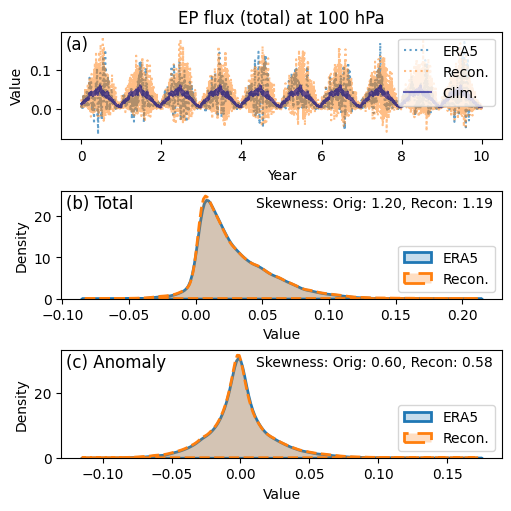

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

timesteps_per_year = 992
plot_years = 10
plot_len = timesteps_per_year * plot_years

#  time series 
ori_sea = epz_clim[:, :].reshape(-1)

x_vals = np.arange(plot_len) / timesteps_per_year  #  x 

# ============== 3  × 2  W1 W2================
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5,5), constrained_layout=True)

# -------- Row 1: Time series --------
ax = axes[0]
ax.plot(x_vals, X_orig_full[:plot_len], linestyle=':', alpha=0.7, label='ERA5')
ax.plot(x_vals, long_data[:plot_len],   linestyle=':', alpha=0.5, label='Recon.')
ax.plot(x_vals, ori_sea[:plot_len],     color='darkblue', alpha=0.6, label='Clim.')
ax.set_title('EP flux (total) at 100 hPa')
ax.set_ylabel('Value')
ax.set_xlabel('Year')
ax.legend(loc='upper right')


# -------- Row 2: Total distributions (PDF) --------
ax = axes[1]
sns.kdeplot(X_orig_full, ax=ax, label='ERA5', fill=True, linewidth=2.0)
sns.kdeplot(long_data,   ax=ax, label='Recon.', fill=True, linewidth=2.0, linestyle='--')
ax.set_xlabel('Value'); ax.set_ylabel('Density'); ax.legend(loc='lower right')
skew_orig = skew(X_orig_full.reshape(-1)); skew_sur = skew(long_data)
ax.text(0.98, 0.95, f"Skewness: Orig: {skew_orig:.2f}, Recon: {skew_sur:.2f}",
        ha='right', va='top', transform=ax.transAxes, fontsize=10,
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))


# -------- Row 3: Anomaly distributions (PDF) --------
ax = axes[2]
sns.kdeplot(A_orig_full,             ax=ax, label='ERA5', fill=True, linewidth=2.0)
sns.kdeplot(long_data - C_long,   ax=ax, label='Recon.', fill=True, linewidth=2.0, linestyle='--')
ax.set_xlabel('Value'); ax.set_ylabel('Density'); ax.legend(loc='lower right')
skew_orig = skew(A_orig_full.reshape(-1)); skew_sur = skew(long_data - C_long)
ax.text(0.98, 0.95, f"Skewness: Orig: {skew_orig:.2f}, Recon: {skew_sur:.2f}",
        ha='right', va='top', transform=ax.transAxes, fontsize=10,
        bbox=dict(facecolor='white', alpha=0.0, edgecolor='none'))


# 
# fig.suptitle('Wave-1 vs Wave-2: Time series & PDFs', y=1.02, fontsize=14)

labels = ['(a)',  '(b) Total',  '(c) Anomaly']
for ax, lab in zip(axes.flat, labels):
    ax.text(0.01, 0.97, lab,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=12)  #  bbox

plt.savefig("forcing.png", dpi=600, bbox_inches="tight", transparent=False)


Original shape: (42, 992)
Target shape per ensemble: (1000, 992)
Original full skewness: 1.1951
Original anom skewness: 0.5983
Original total lag1 = 0.9747
Original anom  lag1 = 0.9679
Original total diff std = 0.0062
Original anom  diff std = 0.0060


Generating ensemble member ens00


[Iter 01] KS_full=0.0056, KS_anom=0.0033 | skew_full=1.2010, skew_anom=0.6069 | lag1_total=0.9904, lag1_anom=0.9864
[Iter 02] KS_full=0.0039, KS_anom=0.0027 | skew_full=1.1971, skew_anom=0.6043 | lag1_total=0.9916, lag1_anom=0.9876
[Iter 03] KS_full=0.0036, KS_anom=0.0025 | skew_full=1.1964, skew_anom=0.6039 | lag1_total=0.9922, lag1_anom=0.9883
[Iter 04] KS_full=0.0032, KS_anom=0.0023 | skew_full=1.1962, skew_anom=0.6036 | lag1_total=0.9926, lag1_anom=0.9888
[Iter 05] KS_full=0.0032, KS_anom=0.0021 | skew_full=1.1961, skew_anom=0.6032 | lag1_total=0.9930, lag1_anom=0.9892
[Iter 06] KS_full=0.0032, KS_anom=0.0019 | skew_full=1.1960, skew_anom=0.6028 | lag1_total=0.9932, lag1_anom=0.9896
[Iter 07] KS_full=0.0031, KS_anom=0.0019 | skew_full=1.1959, skew_anom=0.6025 | lag1_total=0.9935, lag1_anom=0.9899
[Iter 08] KS_full=0.0031, KS_anom=0.0017 | skew_full=1.1959, skew_anom=0.6022 | lag1_total=0.9937, lag1_anom=0.9901
[Iter 09] KS_full=0.0032, KS_anom=0.0018 | skew_full=1.1958, skew_anom=0

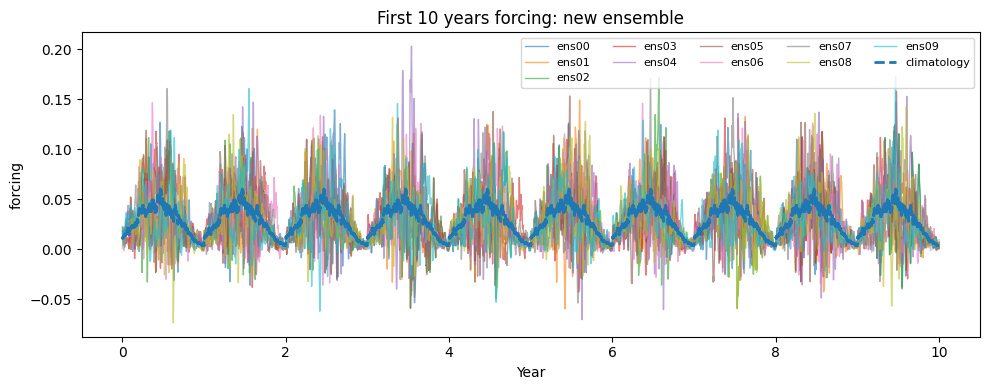

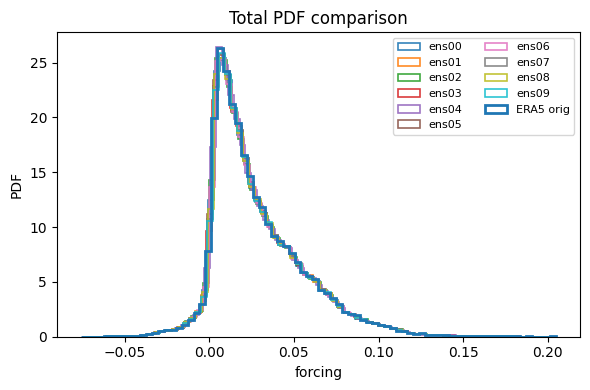

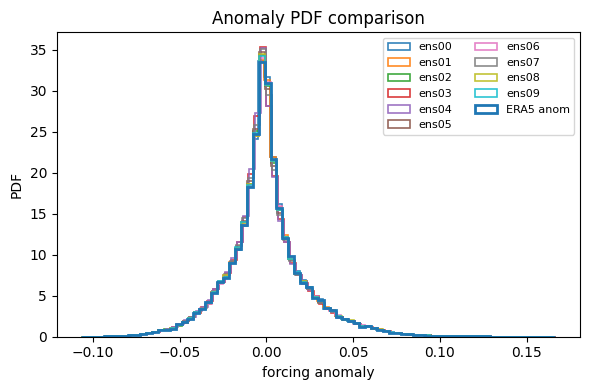


Ensemble summary
member, seed, full_skew, anom_skew, lag1_total, lag1_anom, KS_full, KS_anom
ens00, seed=5974565, full_skew=1.1958, anom_skew=0.6016, lag1_total=0.9941, lag1_anom=0.9906, KS_full=0.0031, KS_anom=0.0016
ens01, seed=2753265, full_skew=1.1958, anom_skew=0.6008, lag1_total=0.9940, lag1_anom=0.9906, KS_full=0.0029, KS_anom=0.0019
ens02, seed=8884735, full_skew=1.1968, anom_skew=0.6008, lag1_total=0.9941, lag1_anom=0.9907, KS_full=0.0028, KS_anom=0.0018
ens03, seed=9188116, full_skew=1.1956, anom_skew=0.6012, lag1_total=0.9940, lag1_anom=0.9906, KS_full=0.0032, KS_anom=0.0019
ens04, seed=1928592, full_skew=1.1960, anom_skew=0.6012, lag1_total=0.9941, lag1_anom=0.9906, KS_full=0.0028, KS_anom=0.0017
ens05, seed=6866109, full_skew=1.1972, anom_skew=0.6010, lag1_total=0.9942, lag1_anom=0.9908, KS_full=0.0033, KS_anom=0.0017
ens06, seed=7533, full_skew=1.1964, anom_skew=0.6006, lag1_total=0.9940, lag1_anom=0.9906, KS_full=0.0033, KS_anom=0.0016
ens07, seed=5899982, full_skew=1.1

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, ks_2samp
from netCDF4 import Dataset
import os
import glob

# ============================================================
# 0) 
# ============================================================

X_orig_2d = total_epz

nyear = 1000
years_target = nyear
N_ENS = 10

n_iter = 10
gamma = 0.6
use_dykstra = False   # 

out_dir = "/scratch/smliu01/1d_model/ens10_1k_set2/"
os.makedirs(out_dir, exist_ok=True)

MASTER_SEED = 20260507

# anomaly  15~30 
WIN = 20

# 
APPLY_SMOOTH = True


# ============================================================
# 1)  climatology/anomaly
# ============================================================

years0, Tpy = X_orig_2d.shape
X_orig_full = X_orig_2d.reshape(-1)

C_doy = X_orig_2d.mean(axis=0)
A_orig_2d = X_orig_2d - C_doy[None, :]
A_orig_full = A_orig_2d.reshape(-1)

target_len = years_target * Tpy
C_long = np.tile(C_doy, years_target)

print("====================================================")
print(f"Original shape: {X_orig_2d.shape}")
print(f"Target shape per ensemble: ({years_target}, {Tpy})")
print(f"Original full skewness: {skew(X_orig_full):.4f}")
print(f"Original anom skewness: {skew(A_orig_full):.4f}")
print("====================================================")


# ============================================================
# 2) 
# ============================================================

def make_sorted_target_from_empirical(x, L):
    x = np.asarray(x).reshape(-1)
    q_src = np.linspace(0, 1, num=x.size, endpoint=False) + 0.5 / x.size
    x_sorted = np.sort(x)

    q_tgt = np.linspace(0, 1, num=L, endpoint=False) + 0.5 / L
    return np.interp(q_tgt, q_src, x_sorted)


def project_to_sorted(y, sorted_target):
    ranks = np.argsort(np.argsort(y))
    return sorted_target[ranks]


def lag1_corr(x):
    x = np.asarray(x).reshape(-1)
    return np.corrcoef(x[:-1], x[1:])[0, 1]


def diff_std(x):
    x = np.asarray(x).reshape(-1)
    return np.std(np.diff(x))


def smooth_121(x):
    y = x.copy()
    y[1:-1] = 0.25 * x[:-2] + 0.5 * x[1:-1] + 0.25 * x[2:]
    return y


# ============================================================
# 3)  total PDF
# ============================================================

full_sorted_target = make_sorted_target_from_empirical(X_orig_full, target_len)
anom_sorted_target_global = make_sorted_target_from_empirical(A_orig_full, target_len)

orig_lag1_total = lag1_corr(X_orig_full)
orig_lag1_anom  = lag1_corr(A_orig_full)
orig_diffstd_total = diff_std(X_orig_full)
orig_diffstd_anom  = diff_std(A_orig_full)

print(f"Original total lag1 = {orig_lag1_total:.4f}")
print(f"Original anom  lag1 = {orig_lag1_anom:.4f}")
print(f"Original total diff std = {orig_diffstd_total:.4f}")
print(f"Original anom  diff std = {orig_diffstd_anom:.4f}")


# ============================================================
# 4) 
# ============================================================

def init_by_year_blocks(X_orig_2d, years_target, seed=0):
    """
     years0  winter  years_target  winter
     year 
    """
    rng = np.random.default_rng(seed)
    years0, Tpy = X_orig_2d.shape
    pick = rng.integers(0, years0, size=years_target)
    y0 = X_orig_2d[pick, :].reshape(-1).copy()
    return y0


# ============================================================
# 5) anomaly  DOY
# ============================================================

def project_anom_by_window(a, Tpy, years_target, X_orig_2d, C_doy, win=20):
    """
     seasonal time  anomaly 
     DOY 
    """
    a = a.copy()

    for start in range(0, Tpy, win):
        end = min(start + win, Tpy)

        idx = []
        for y in range(years_target):
            idx.extend(range(y * Tpy + start, y * Tpy + end))
        idx = np.array(idx)

        #  anomaly 
        a_ref = (X_orig_2d[:, start:end] - C_doy[None, start:end]).reshape(-1)

        q_src = np.linspace(0, 1, num=len(a_ref), endpoint=False) + 0.5 / len(a_ref)
        q_tgt = np.linspace(0, 1, num=len(idx), endpoint=False) + 0.5 / len(idx)

        tgt_stretched = np.interp(q_tgt, q_src, np.sort(a_ref))

        ranks = np.argsort(np.argsort(a[idx]))
        a[idx] = tgt_stretched[ranks]

    return a


# ============================================================
# 6) 
# ============================================================

def alternating_projections_pdf_better(
    X_orig_2d,
    C_long,
    full_sorted_target,
    years_target,
    Tpy,
    C_doy,
    n_iter=10,
    gamma=0.6,
    seed=0,
    win=20,
    apply_smooth=True,
    verbose=True
):
    # 
    y = init_by_year_blocks(X_orig_2d, years_target, seed=seed)

    hist = []

    for k in range(1, n_iter + 1):

        # --------------------------
        # Step 1: match total PDF
        # --------------------------
        y_full_step = project_to_sorted(y, full_sorted_target)
        y = (1.0 - gamma) * y + gamma * y_full_step

        # --------------------------
        # Step 2: match anomaly distribution by window
        # --------------------------
        a = y - C_long
        a_proj = project_anom_by_window(
            a=a,
            Tpy=Tpy,
            years_target=years_target,
            X_orig_2d=X_orig_2d,
            C_doy=C_doy,
            win=win
        )
        y_anom_step = C_long + a_proj
        y = (1.0 - gamma) * y + gamma * y_anom_step

        # --------------------------
        # Step 3: optional light smoothing
        # --------------------------
        if apply_smooth:
            y = smooth_121(y)

        # diagnostics
        ks_full = ks_2samp(y, full_sorted_target).statistic
        ks_anom = ks_2samp(y - C_long, anom_sorted_target_global).statistic
        sk_full = skew(y)
        sk_anom = skew(y - C_long)
        lag1_t = lag1_corr(y)
        lag1_a = lag1_corr(y - C_long)
        dstd_t = diff_std(y)
        dstd_a = diff_std(y - C_long)

        hist.append((ks_full, ks_anom, sk_full, sk_anom, lag1_t, lag1_a, dstd_t, dstd_a))

        if verbose:
            print(
                f"[Iter {k:02d}] "
                f"KS_full={ks_full:.4f}, KS_anom={ks_anom:.4f} | "
                f"skew_full={sk_full:.4f}, skew_anom={sk_anom:.4f} | "
                f"lag1_total={lag1_t:.4f}, lag1_anom={lag1_a:.4f}"
            )

    return y, np.array(hist)


# ============================================================
# 7)  NetCDF
# ============================================================

def save_forcing_nc(path, forcing_2d):
    if os.path.exists(path):
        raise FileExistsError(f"File already exists, refuse to overwrite: {path}")

    print(f"Saving: {path}")
    print(f"  shape = {forcing_2d.shape}")

    with Dataset(path, "w", format="NETCDF4") as nc:
        nc.createDimension("y", forcing_2d.shape[0])
        nc.createDimension("x", forcing_2d.shape[1])

        var = nc.createVariable("forcing", "f4", ("y", "x"))
        var.long_name = "Wave forcing components"
        var[:, :] = forcing_2d.astype(np.float32)


# ============================================================
# 8)  forcing ensemble
# ============================================================

rng_master = np.random.default_rng(MASTER_SEED)

diag = []

for mem in range(N_ENS):
    print("\n\n====================================================")
    print(f"Generating ensemble member ens{mem:02d}")
    print("====================================================")

    seed = int(rng_master.integers(1, 10_000_000))

    long_data, hist = alternating_projections_pdf_better(
        X_orig_2d=X_orig_2d,
        C_long=C_long,
        full_sorted_target=full_sorted_target,
        years_target=years_target,
        Tpy=Tpy,
        C_doy=C_doy,
        n_iter=n_iter,
        gamma=gamma,
        seed=seed,
        win=WIN,
        apply_smooth=APPLY_SMOOTH,
        verbose=True
    )

    forcing_2d = long_data.reshape(years_target, Tpy)

    full_sk = skew(long_data)
    anom_sk = skew(long_data - C_long)
    lag1_t = lag1_corr(long_data)
    lag1_a = lag1_corr(long_data - C_long)
    dstd_t = diff_std(long_data)
    dstd_a = diff_std(long_data - C_long)

    print("\nFinal diagnostics:")
    print(f"  seed = {seed}")
    print(f"  full skew: original={skew(X_orig_full):.4f}, new={full_sk:.4f}")
    print(f"  anom skew: original={skew(A_orig_full):.4f}, new={anom_sk:.4f}")
    print(f"  total lag1: original={orig_lag1_total:.4f}, new={lag1_t:.4f}")
    print(f"  anom  lag1: original={orig_lag1_anom:.4f}, new={lag1_a:.4f}")
    print(f"  total diff std: original={orig_diffstd_total:.4f}, new={dstd_t:.4f}")
    print(f"  anom  diff std: original={orig_diffstd_anom:.4f}, new={dstd_a:.4f}")

    out_path = os.path.join(out_dir, f"forcing_total_{nyear}_ens{mem:02d}.nc")
    save_forcing_nc(out_path, forcing_2d)

    diag.append({
        "member": mem,
        "seed": seed,
        "full_skew": float(full_sk),
        "anom_skew": float(anom_sk),
        "lag1_total": float(lag1_t),
        "lag1_anom": float(lag1_a),
        "diffstd_total": float(dstd_t),
        "diffstd_anom": float(dstd_a),
        "ks_full_last": float(hist[-1, 0]),
        "ks_anom_last": float(hist[-1, 1])
    })


# ============================================================
# 9) 
# ============================================================

files = sorted(glob.glob(os.path.join(out_dir, f"forcing_total_{nyear}_ens*.nc")))

print("\n====================================================")
print("New forcing files:")
for f in files:
    print(" ", f)
print("====================================================")

forcings = []
for fp in files:
    with Dataset(fp, "r") as nc:
        forcings.append(np.array(nc.variables["forcing"][:], dtype=float))

forcings = np.array(forcings)

print("Read-back shape:", forcings.shape)

plot_years = 10
plot_len = plot_years * Tpy
x_vals = np.arange(plot_len) / Tpy
clim_10yr = np.tile(C_doy, plot_years)

plt.figure(figsize=(10, 4))
for i in range(forcings.shape[0]):
    y = forcings[i].reshape(-1)[:plot_len]
    plt.plot(x_vals, y, alpha=0.6, linewidth=1.0, label=f"ens{i:02d}")
plt.plot(x_vals, clim_10yr, linestyle="--", linewidth=2.0, label="climatology")
plt.xlabel("Year")
plt.ylabel("forcing")
plt.title(f"First {plot_years} years forcing: new ensemble")
plt.legend(ncol=5, fontsize=8)
plt.tight_layout()

bins = 80
plt.figure(figsize=(6, 4))
for i in range(forcings.shape[0]):
    y = forcings[i].reshape(-1)
    plt.hist(y, bins=bins, density=True, histtype="step", linewidth=1.2, alpha=0.9, label=f"ens{i:02d}")
plt.hist(X_orig_full, bins=bins, density=True, histtype="step", linewidth=2.0, label="ERA5 orig")
plt.xlabel("forcing")
plt.ylabel("PDF")
plt.title("Total PDF comparison")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

plt.figure(figsize=(6, 4))
for i in range(forcings.shape[0]):
    y = forcings[i].reshape(-1)
    A = y - np.tile(C_doy, nyear)
    plt.hist(A, bins=bins, density=True, histtype="step", linewidth=1.2, alpha=0.9, label=f"ens{i:02d}")
plt.hist(A_orig_full, bins=bins, density=True, histtype="step", linewidth=2.0, label="ERA5 anom")
plt.xlabel("forcing anomaly")
plt.ylabel("PDF")
plt.title("Anomaly PDF comparison")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

plt.show()


# ============================================================
# 10)  summary
# ============================================================

print("\n====================================================")
print("Ensemble summary")
print("member, seed, full_skew, anom_skew, lag1_total, lag1_anom, KS_full, KS_anom")
print("====================================================")

for row in diag:
    print(
        f"ens{row['member']:02d}, "
        f"seed={row['seed']}, "
        f"full_skew={row['full_skew']:.4f}, "
        f"anom_skew={row['anom_skew']:.4f}, "
        f"lag1_total={row['lag1_total']:.4f}, "
        f"lag1_anom={row['lag1_anom']:.4f}, "
        f"KS_full={row['ks_full_last']:.4f}, "
        f"KS_anom={row['ks_anom_last']:.4f}"
    )

forcing1 shape: (1000, 992)
forcing2 shape: (1000, 992)


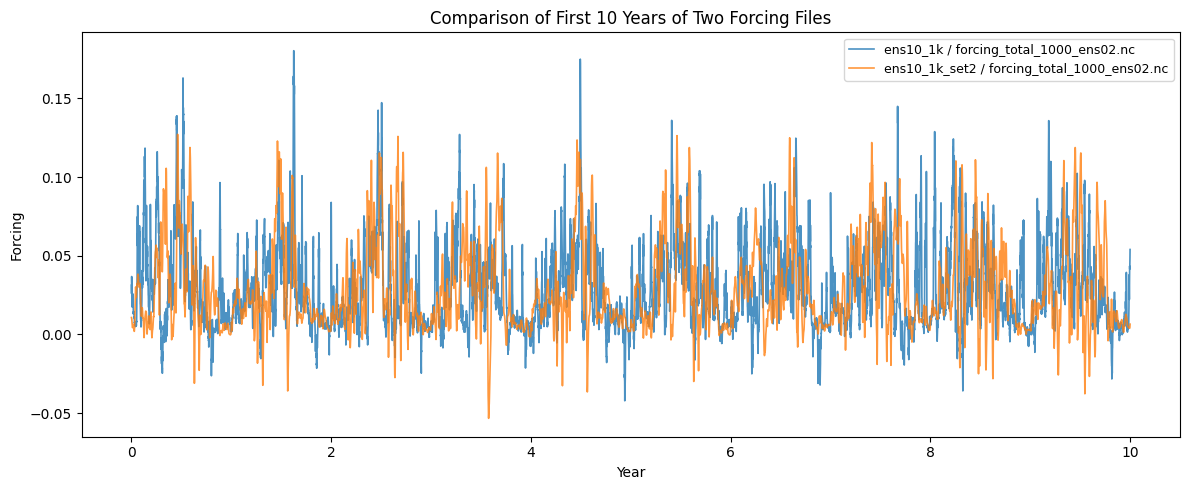

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

# =========================================
# 1. 
# =========================================
file1 = "/scratch/smliu01/1d_model/ens10_1k/forcing_total_1000_ens00.nc"
file2 = "/scratch/smliu01/1d_model/ens10_1k_set2/forcing_total_1000_ens00.nc"

# =========================================
# 2.  forcing
# =========================================
with Dataset(file1, "r") as nc:
    forcing1 = np.array(nc.variables["forcing"][:], dtype=float)

with Dataset(file2, "r") as nc:
    forcing2 = np.array(nc.variables["forcing"][:], dtype=float)

print("forcing1 shape:", forcing1.shape)
print("forcing2 shape:", forcing2.shape)

# =========================================
# 3. 10
#    forcing shape = (nyear, timesteps_per_year)
# =========================================
plot_years = 10
timesteps_per_year = forcing1.shape[1]

y1 = forcing1[:plot_years, :].reshape(-1)
y2 = forcing2[:plot_years, :].reshape(-1)

x = np.arange(plot_years * timesteps_per_year) / timesteps_per_year

# =========================================
# 4. 
# =========================================
plt.figure(figsize=(12, 5))
plt.plot(x, y1, label="ens10_1k / forcing_total_1000_ens02.nc", alpha=0.8, linewidth=1.2)
plt.plot(x, y2, label="ens10_1k_set2 / forcing_total_1000_ens02.nc", alpha=0.8, linewidth=1.2)

plt.xlabel("Year")
plt.ylabel("Forcing")
plt.title("Comparison of First 10 Years of Two Forcing Files")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()